In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,make_scorer, f1_score,precision_score, recall_score
from sklearn.model_selection import GridSearchCV,StratifiedKFold
import pickle, os

In [68]:
train_data = pd.read_csv('../data/processed/train_preprocessed.csv')
valid_data = pd.read_csv('../data/processed/val_preprocessed.csv')
test_data = pd.read_csv('../data/processed/test_preprocessed.csv')

TARGET = "label"

In [69]:
X_train = train_data.drop(columns=[TARGET])
y_train = train_data[TARGET]
X_val = valid_data.drop(columns=[TARGET])
y_val = valid_data[TARGET]
X_test = test_data.drop(columns=[TARGET])
y_test = test_data[TARGET]

In [70]:
print(X_train.mean())
print(pd.Series(y_train).value_counts())

N                0.210672
P                0.058437
K                0.557026
temperature      0.015813
humidity        -0.307459
ph               0.043348
rainfall         0.144820
total_npk        0.072139
ratio_n_p        0.456858
ratio_n_k        0.158386
ratio_p_k        0.214370
temp_humidity   -0.098149
log_rainfall    -0.083192
dtype: float64
label
16    80
7     80
9     80
13    80
6     80
1     80
10    80
14    80
5     80
15    80
0     80
2     80
18    80
11    80
20    80
21    80
8     80
12    80
19    80
17    80
4     80
3     80
Name: count, dtype: int64


# Cài đặt mô hình

Cài đặt thủ công các mô hình

In [71]:
# Mô hình Logistic Regression

class ManualLogisticRegression:
    def __init__(self, lr: float = 0.1, n_iters: int = 500):
        self.lr = lr
        self.n_iters = n_iters
        self.W = None # Ma trận trọng số kèm bias
        self.classes_ = None

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X: np.ndarray, y: np.ndarray):
        # Thêm cột 1 vào X để tính bias tự động
        X_bias = np.c_[np.ones(X.shape[0]), X]
        m, n_features = X_bias.shape
        self.classes_ = np.unique(y)
        K = len(self.classes_)

        # Khởi tạo ma trận trọng số có kích thước = Số lớp x Số đặc trưng
        self.W = np.zeros((K, n_features))

        for idx, cls in enumerate(self.classes_):
            y_bin = (y == cls).astype(float)
            w_k = np.zeros(n_features)

            for _ in range(self.n_iters):
                # Dự đoán xác suất cho lớp k
                p_hat = self._sigmoid(X_bias @ w_k)

                # Tính Gradient
                gradient = (X_bias.T @ (p_hat - y_bin)) / m

                # Cập nhật trọng số
                w_k -= self.lr * gradient

            self.W[idx] = w_k
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_bias = np.c_[np.ones(X.shape[0]), X]
        # Tính toán scores (logit values)
        scores = X_bias @ self.W.T
        # Chọn lớp có điểm số cao nhất
        return self.classes_[np.argmax(scores, axis=1)]

In [72]:
# Mô hình SVM

class ManualSVM:
    def __init__(self, lr=0.01, n_iters=1000, lam=0.01, gamma=0.1):
        self.lr = lr
        self.n_iters = n_iters
        self.lam = lam
        self.gamma = gamma # Siêu tham số cho RBF Kernel
        self.alphas = None # Đóng vai trò thay thế cho w
        self.classes_ = None
        self.X_train = None # Lưu lại X_train để tính kernel khi predict

    def _rbf_kernel(self, X1, X2):
        # Tính bình phương khoảng cách Euclidean bằng ma trận để tăng tốc
        sq_dists = (np.sum(X1**2, axis=1, keepdims=True) +
                    np.sum(X2**2, axis=1) -
                    2 * (X1 @ X2.T))
        # Tránh lỗi số học (số âm cực nhỏ do floating point)
        sq_dists = np.clip(sq_dists, 0, None)
        return np.exp(-self.gamma * sq_dists)

    def fit(self, X, y):
        self.X_train = X.copy()
        m, n = X.shape
        self.classes_ = np.unique(y)
        K_classes = len(self.classes_)

        # Tính trước ma trận Gram K
        K = self._rbf_kernel(X, X)

        # Gộp Bias (b) vào model
        K = K + 1.0

        # Ma trận alphas kích thước (Số lớp x Số mẫu)
        self.alphas = np.zeros((K_classes, m))

        for idx, cls in enumerate(self.classes_):
            y_bin = np.where(y == cls, 1, -1)
            alpha_k = np.zeros(m)

            for epoch in range(self.n_iters):
                # Tính scores: f(x) = K @ alpha
                scores = K @ alpha_k
                margins = y_bin * scores

                # Tìm các điểm vi phạm
                misclassified = margins < 1

                # Tính Gradient theo alpha_k
                grad_alpha = self.lam * alpha_k - (y_bin * misclassified) / m

                # Cập nhật alphas
                alpha_k -= self.lr * grad_alpha

            self.alphas[idx] = alpha_k

        return self

    def predict(self, X):
        # Tính ma trận Kernel giữa tập Test (X) và tập Train (X_train)
        K_test = self._rbf_kernel(X, self.X_train)
        K_test = K_test + 1.0 # Nhớ cộng 1 cho bias như lúc fit

        # Dự đoán điểm số
        # scores = K_test @ alphas^T
        scores = K_test @ self.alphas.T

        # Lấy class có điểm cao nhất
        return self.classes_[np.argmax(scores, axis=1)]

In [73]:
# Mô hình Random Forest
class _DTNode:
    __slots__ = ("feature_idx", "threshold", "left", "right", "value")

    def __init__(self):
        self.feature_idx: int = None # index feature để split
        self.threshold : float = None # ngưỡng split
        self.left = None # node con trái
        self.right = None # node con phải
        self.value = None # nhãn đa số (leaf node)

class _ManualDecisionTree:
    def __init__(self, max_depth: int = 10, min_samples_split: int = 2,  max_features=None, random_state: int = None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.root = None
        self.rng = np.random.default_rng(random_state)

    @staticmethod
    def _gini(y: np.ndarray) -> float:
        m = len(y)
        if m == 0:
            return 0.0
        counts = np.bincount(y)
        probs = counts / m
        return 1.0 - float(np.sum(probs ** 2))

    def _best_split(self, X: np.ndarray, y: np.ndarray):
        m, n = X.shape
        best_gain = -np.inf
        best_feat = None
        best_thresh = None

        # Chọn tập features xét (Random Forest feature subsampling)
        n_features = n if self.max_features is None else \
                     min(self.max_features, n)
        feat_indices = self.rng.choice(n, size=n_features, replace=False)

        parent_gini = self._gini(y)

        for j in feat_indices:
            thresholds = np.unique(X[:, j])

            for t in thresholds:
                left_mask = X[:, j] <= t
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                g_l = self._gini(y[left_mask])
                g_r = self._gini(y[right_mask])
                gain = parent_gini \
                         - (left_mask.sum() / m) * g_l \
                         - (right_mask.sum() / m) * g_r

                if gain > best_gain:
                    best_gain = gain
                    best_feat = j
                    best_thresh = t

        return best_feat, best_thresh

    def _build(self, X: np.ndarray, y: np.ndarray,
               depth: int) -> _DTNode:
        node = _DTNode()

        # Điều kiện dừng → leaf
        if (depth >= self.max_depth or
                len(y) < self.min_samples_split or
                len(np.unique(y)) == 1):
            node.value = Counter(y.tolist()).most_common(1)[0][0]
            return node

        feat, thresh = self._best_split(X, y)

        # Không tìm được split tốt → leaf
        if feat is None:
            node.value = Counter(y.tolist()).most_common(1)[0][0]
            return node

        left_mask = X[:, feat] <= thresh
        right_mask = ~left_mask

        node.feature_idx = feat
        node.threshold = thresh
        node.left = self._build(X[left_mask], y[left_mask],depth + 1)
        node.right = self._build(X[right_mask], y[right_mask], depth + 1)
        return node

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.root = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x: np.ndarray, node: _DTNode):
        if node.value is not None:   # leaf
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.array([self._predict_one(x, self.root) for x in X])


class ManualRandomForest:
    def __init__(self, n_estimators: int = 50,
                 max_depth: int = 10,
                 min_samples_split: int = 2,
                 max_features: str = "sqrt",
                 random_state: int = 42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split= min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees_ = []
        self.classes_ = None

    def _resolve_max_features(self, n: int) -> int:
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(n)))
        if self.max_features == "log2":
            return max(1, int(np.log2(n)))
        if isinstance(self.max_features, int):
            return self.max_features
        return n   # fallback: dùng tất cả

    def fit(self, X: np.ndarray, y: np.ndarray):
        m, n = X.shape
        self.classes_ = np.unique(y)
        mf  = self._resolve_max_features(n)
        rng = np.random.default_rng(self.random_state)

        self.trees_ = []
        for i in range(self.n_estimators):
            boot_idx = rng.integers(0, m, size=m)
            X_boot = X[boot_idx]
            y_boot = y[boot_idx]

            # Tạo và train cây với seed riêng
            tree = _ManualDecisionTree(
                max_depth = self.max_depth,
                min_samples_split  = self.min_samples_split,
                max_features = mf,
                random_state = int(rng.integers(0, 10_000))
            )
            tree.fit(X_boot, y_boot)
            self.trees_.append(tree)

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Ma trận dự đoán: (n_estimators, n_samples)
        all_preds = np.array([tree.predict(X) for tree in self.trees_])

        # Majority vote theo từng sample
        result = []
        for col in all_preds.T:
            vote = Counter(col.tolist()).most_common(1)[0][0]
            result.append(vote)
        return np.array(result)


Cài đặt các mô hình bằng thư viện

In [74]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scorer = make_scorer(f1_score, average="weighted")

# Logistic regression
param_grid_lr = {
    "C" : [0.01, 0.1, 1, 10, 100],
    "solver" : ["lbfgs", "saga"],
    "penalty": ["l2"],
    "max_iter" : [2000, 5000],
}
gs_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1
)

# SVM
param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["rbf", "poly"],
    "gamma" : ["scale", "auto"],
    "degree": [2, 3],
}
gs_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1
)

# Random Forest
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth" : [8, 10, 15, None],
    "max_features": ["sqrt", "log2"],
    "min_samples_leaf": [1, 2],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1
)

In [75]:
# Label encoding biến target để dùng trong các mô hình cài đặt thủ công
# Đảm bảo dạng numpy array
X_tr = np.array(X_train)
X_v = np.array(X_val)
X_te = np.array(X_test)
y_tr = np.array(y_train)

# Huấn luyện mô hình

In [76]:
# Logistic Regression
man_lr = ManualLogisticRegression(lr=0.1, n_iters=500)
man_lr.fit(X_tr, y_tr)

man_lr_val_pred = man_lr.predict(X_v)
man_lr_test_pred = man_lr.predict(X_te)
# SVM
man_svm = ManualSVM(lr=0.001, n_iters=300, lam=0.01)
man_svm.fit(X_tr, y_tr)

man_svm_val_pred = man_svm.predict(X_v)
man_svm_test_pred = man_svm.predict(X_te)
print(f"Val predictions shape : {man_svm_val_pred.shape}")
print(f"Test predictions shape : {man_svm_test_pred.shape}")

# Random Forest
man_rf = ManualRandomForest(
    n_estimators= 50,
    max_depth = 8,
    min_samples_split = 4,
    max_features = "sqrt",
    random_state = 42
)
man_rf.fit(X_tr, y_tr)

man_rf_val_pred = man_rf.predict(X_v)
man_rf_test_pred = man_rf.predict(X_te)
print(f"Val predictions shape : {man_rf_val_pred.shape}")
print(f"Test predictions shape : {man_rf_test_pred.shape}")

Val predictions shape : (220,)
Test predictions shape : (220,)
Val predictions shape : (220,)
Test predictions shape : (220,)


In [77]:
# Logistic regression
gs_lr.fit(X_train, y_train)
print(f"LR best params : {gs_lr.best_params_}")
print(f"Best CV F1: {gs_lr.best_score_:.4f}")

# SVM
gs_svm.fit(X_train, y_train)
print(f"SVM best params : {gs_svm.best_params_}")
print(f"Best CV F1 : {gs_svm.best_score_:.4f}")

# Random Forest
gs_rf.fit(X_train, y_train)
print(f"RF best params : {gs_rf.best_params_}")
print(f"Best CV F1 : {gs_rf.best_score_:.4f}")


tuning_summary = pd.DataFrame([
    {"Model": "Logistic Regression", "Best Params": str(gs_lr.best_params_), "CV F1": round(gs_lr.best_score_, 4)},
    {"Model": "Random Forest", "Best Params": str(gs_rf.best_params_), "CV F1": round(gs_rf.best_score_, 4)},
    {"Model": "SVM", "Best Params": str(gs_svm.best_params_), "CV F1": round(gs_svm.best_score_, 4)},
])
display(tuning_summary)

lib_lr = gs_lr.best_estimator_
lib_rf = gs_rf.best_estimator_
lib_svm = gs_svm.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
LR best params : {'C': 10, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1: 0.9783
Fitting 5 folds for each of 32 candidates, totalling 160 fits
SVM best params : {'C': 100, 'degree': 2, 'gamma': 'auto', 'kernel': 'poly'}
Best CV F1 : 0.9834
Fitting 5 folds for each of 48 candidates, totalling 240 fits
RF best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV F1 : 0.9931


,Model,Best Params,CV F1
0,Logistic Regression,"{'C': 10, 'max_iter': 2000, 'penalty': 'l2', '...",0.9783
1,Random Forest,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.9931
2,SVM,"{'C': 100, 'degree': 2, 'gamma': 'auto', 'kern...",0.9834


# Đánh giá và tổng hợp kết quả

In [78]:
def evaluate(name: str, val_pred, test_pred, y_val_true, y_test_true) -> dict:
    return {
        "Model" : name,
        "Val Accuracy" : round(accuracy_score(y_val_true, val_pred), 4),
        "Test Accuracy" : round(accuracy_score(y_test_true, test_pred), 4),
        "Val F1 (w)" : round(f1_score(y_val_true, val_pred, average="weighted", zero_division=0), 4),
        "Test F1 (w)" : round(f1_score(y_test_true, test_pred,average="weighted", zero_division=0), 4),
        "Val Precision" : round(precision_score(y_val_true, val_pred, average="weighted", zero_division=0), 4),
        "Test Precision": round(precision_score(y_test_true, test_pred, average="weighted", zero_division=0), 4),
        "Val Recall" : round(recall_score(y_val_true, val_pred, average="weighted", zero_division=0), 4),
        "Test Recall" : round(recall_score(y_test_true, test_pred, average="weighted", zero_division=0), 4),
    }

# Dự đoán trên các mô hình cài đặt bằng thư viện
lib_lr_val_pred = le.transform(lib_lr.predict(X_val))
lib_lr_test_pred = le.transform(lib_lr.predict(X_test))

lib_svm_val_pred = le.transform(lib_svm.predict(X_val))
lib_svm_test_pred = le.transform(lib_svm.predict(X_test))

lib_rf_val_pred = le.transform(lib_rf.predict(X_val))
lib_rf_test_pred = le.transform(lib_rf.predict(X_test))

# Tổng hợp kết quả
results = [
    evaluate("Logistic Regression (Manual)", man_lr_val_pred, man_lr_test_pred, y_val, y_test),
    evaluate("Logistic Regression (sklearn)", lib_lr_val_pred, lib_lr_test_pred, y_val, y_test),
    evaluate("SVM (Manual)", man_svm_val_pred, man_svm_test_pred, y_val, y_test),
    evaluate("SVM (sklearn)",lib_svm_val_pred, lib_svm_test_pred, y_val, y_test),
    evaluate("Random Forest (Manual)", man_rf_val_pred, man_rf_test_pred, y_val, y_test),
    evaluate("Random Forest (sklearn)", lib_rf_val_pred, lib_rf_test_pred, y_val, y_test),
]

df_results = pd.DataFrame(results)

metric_cols = ["Val Accuracy", "Test Accuracy",
               "Val F1 (w)", "Test F1 (w)",
               "Val Precision","Test Precision",
               "Val Recall", "Test Recall"]

styled = (
    df_results.style
    .set_caption("Model Performance Comparison — Crop Recommendation")
    .set_properties(**{"text-align": "center"})
    .format({col: "{:.4f}" for col in metric_cols})
)

display(styled)

best_idx = df_results["Test Accuracy"].idxmax()
best_model = df_results.loc[best_idx, "Model"]
best_acc = df_results.loc[best_idx, "Test Accuracy"]
print(f"\nBest model (Test Accuracy): {best_model}  →  {best_acc:.4f}")

,Model,Val Accuracy,Test Accuracy,Val F1 (w),Test F1 (w),Val Precision,Test Precision,Val Recall,Test Recall
0,Logistic Regression (Manual),0.8545,0.8864,0.8423,0.8826,0.8974,0.9193,0.8545,0.8864
1,Logistic Regression (sklearn),0.9864,0.9773,0.9863,0.9772,0.9883,0.9792,0.9864,0.9773
2,SVM (Manual),0.8318,0.8227,0.8093,0.8055,0.8816,0.8610,0.8318,0.8227
3,SVM (sklearn),0.9955,0.9818,0.9954,0.9817,0.9959,0.9837,0.9955,0.9818
4,Random Forest (Manual),0.9955,0.9864,0.9954,0.9863,0.9959,0.9876,0.9955,0.9864
5,Random Forest (sklearn),0.9955,0.9909,0.9954,0.9909,0.9959,0.9917,0.9955,0.9909



Best model (Test Accuracy): Random Forest (sklearn)  →  0.9909


In [79]:
# Tổng hợp dữ liệu
algorithms = ["Logistic\nRegression", "SVM", "Random\nForest"]

manual_val = [df_results.loc[0, "Val Accuracy"],
              df_results.loc[2, "Val Accuracy"],
              df_results.loc[4, "Val Accuracy"]]
manual_test = [df_results.loc[0, "Test Accuracy"],
               df_results.loc[2, "Test Accuracy"],
               df_results.loc[4, "Test Accuracy"]]

lib_val = [df_results.loc[1, "Val Accuracy"],
           df_results.loc[3, "Val Accuracy"],
           df_results.loc[5, "Val Accuracy"]]
lib_test = [df_results.loc[1, "Test Accuracy"],
            df_results.loc[3, "Test Accuracy"],
            df_results.loc[5, "Test Accuracy"]]

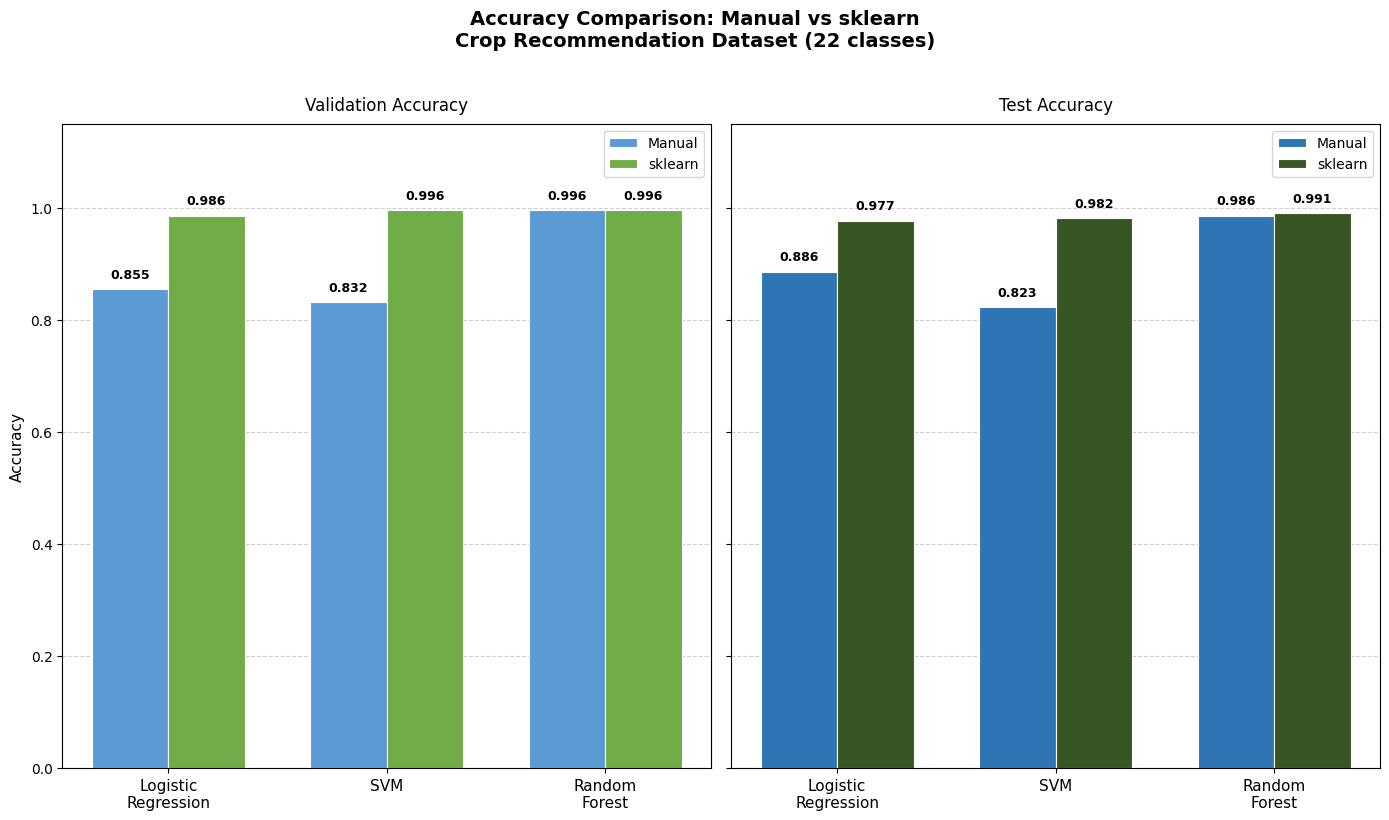

In [80]:
# Layout: 1×2 subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
fig.suptitle("Accuracy Comparison: Manual vs sklearn\n"
             "Crop Recommendation Dataset (22 classes)",
             fontsize=14, fontweight="bold", y=1.02)

x = np.arange(len(algorithms))
width = 0.35

# Màu sắc
COLOR_MAN = {"val": "#5B9BD5", "test": "#2E75B6"}   # xanh dương
COLOR_LIB = {"val": "#70AD47", "test": "#375623"}    # xanh lá

# Subplot 1: Validation Accuracy
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, manual_val, width,
                color=COLOR_MAN["val"], edgecolor="white",
                linewidth=0.8, label="Manual")
bars2 = ax1.bar(x + width/2, lib_val, width,
                color=COLOR_LIB["val"], edgecolor="white",
                linewidth=0.8, label="sklearn")

ax1.set_title("Validation Accuracy", fontsize=12, pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(algorithms, fontsize=11)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.set_ylim(0, 1.15)
ax1.yaxis.grid(True, linestyle="--", alpha=0.6)
ax1.set_axisbelow(True)
ax1.legend(fontsize=10)

# Ghi giá trị trên bar
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.015,
             f"{bar.get_height():.3f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.015,
             f"{bar.get_height():.3f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

# Subplot 2: Test Accuracy
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, manual_test, width,
                color=COLOR_MAN["test"], edgecolor="white",
                linewidth=0.8, label="Manual")
bars4 = ax2.bar(x + width/2, lib_test,    width,
                color=COLOR_LIB["test"], edgecolor="white",
                linewidth=0.8, label="sklearn")

ax2.set_title("Test Accuracy", fontsize=12, pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(algorithms, fontsize=11)
ax2.yaxis.grid(True, linestyle="--", alpha=0.6)
ax2.set_axisbelow(True)
ax2.legend(fontsize=10)

for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.015,
             f"{bar.get_height():.3f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.015,
             f"{bar.get_height():.3f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

In [81]:
delta_val  = [round(l - m, 4) for l, m in zip(lib_val,  manual_val)]
delta_test = [round(l - m, 4) for l, m in zip(lib_test, manual_test)]

df_delta = pd.DataFrame(
    {
    "Logistic Regression": [f"{delta_val[0]:+.4f}",  f"{delta_test[0]:+.4f}"],
    "SVM": [f"{delta_val[1]:+.4f}",  f"{delta_test[1]:+.4f}"],
    "Random Forest" : [f"{delta_val[2]:+.4f}",  f"{delta_test[2]:+.4f}"],
    },
    index=["Val Accuracy", "Test Accuracy"]
)

print("Accuracy = sklearn − Manual  (dương = sklearn tốt hơn)")
display(df_delta)

Accuracy = sklearn − Manual  (dương = sklearn tốt hơn)


,Logistic Regression,SVM,Random Forest
Val Accuracy,+0.1319,+0.1637,+0.0000
Test Accuracy,+0.0909,+0.1591,+0.0045


# Export models

In [82]:
os.makedirs("backend/models", exist_ok=True)

models_to_save = {
    "lr_model.pkl" : lib_lr, # LogisticRegression
    "svm_model.pkl" : lib_svm,  # SVC
    "rf_model.pkl" : lib_rf, # RandomForestClassifier
}

for filename, model in models_to_save.items():
    with open(f"backend/models/{filename}", "wb") as f:
        pickle.dump(model, f)
    print(f"Saved: backend/models/{filename}")

Saved: backend/models/lr_model.pkl
Saved: backend/models/svm_model.pkl
Saved: backend/models/rf_model.pkl
